In [1]:
## Support Vector Machine (SVM)

In [2]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from tensorflow.keras.datasets import mnist

# ML Models
from sklearn import svm

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# Load Datasets

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [4]:
# Normalize Data

X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

In [5]:
# Flatten for SVM

X_train_flat = X_train_norm.reshape(60000, 784)
X_test_flat = X_test_norm.reshape(10000, 784)

In [6]:
# Train SVM

# Use subset to avoid long training time
svm_model = svm.SVC(kernel='linear')

svm_model.fit(X_train_flat[:10000], y_train[:10000])

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
# Predictions

y_pred_svm = svm_model.predict(X_test_flat)

In [8]:
# Accuracy

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.917


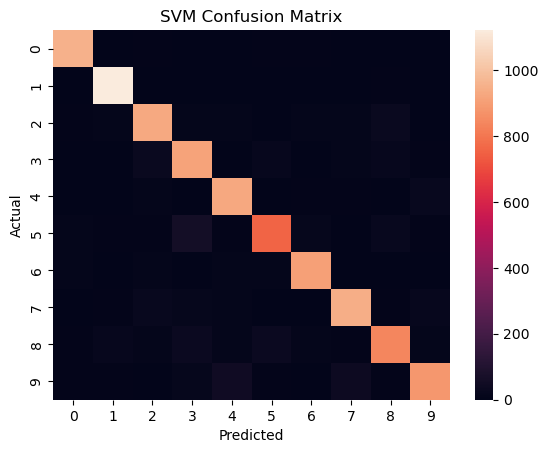

In [9]:
# Confusion Matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
## Deep Neural Network (DNN)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

dnn_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [12]:
# Build Model

# Define DNN model
dnn_model = Sequential()

# Input layer + Hidden layer
dnn_model.add(Dense(128, activation='relu', input_shape=(784,)))

# Second hidden layer
dnn_model.add(Dense(64, activation='relu'))

# Output layer
dnn_model.add(Dense(10, activation='softmax'))

C:\Users\deboj\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile Model

dnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Train Model

history = dnn_model.fit(
    X_train_flat,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9007 - loss: 0.3479 - val_accuracy: 0.9608 - val_loss: 0.1406
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9576 - loss: 0.1455 - val_accuracy: 0.9688 - val_loss: 0.1039
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9684 - loss: 0.1046 - val_accuracy: 0.9738 - val_loss: 0.0940
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0782 - val_accuracy: 0.9748 - val_loss: 0.0948
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9806 - loss: 0.0619 - val_accuracy: 0.9762 - val_loss: 0.0863


In [15]:
# Evaluate Model

loss, dnn_accuracy = dnn_model.evaluate(X_test_flat, y_test_cat)

print("DNN Accuracy:", dnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9731 - loss: 0.0909
DNN Accuracy: 0.9731000065803528


In [16]:
# Predictions

y_pred_dnn = dnn_model.predict(X_test_flat)

# Convert probabilities → class labels
y_pred_dnn = np.argmax(y_pred_dnn, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


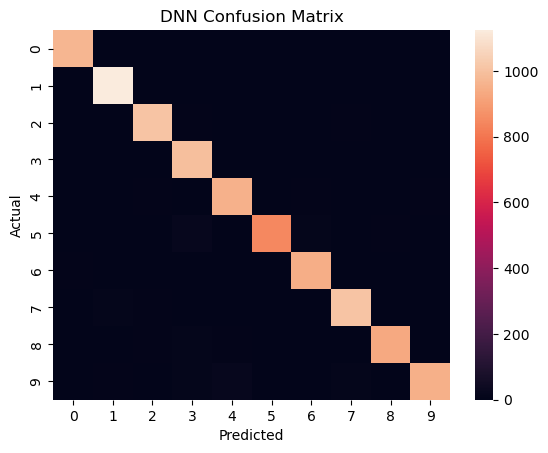

In [17]:
# Confusion Matrix

cm_dnn = confusion_matrix(y_test, y_pred_dnn)

plt.figure()
sns.heatmap(cm_dnn)
plt.title("DNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
## Convolutional Neural Network (CNN)

In [19]:
# Prepare Data

# Reshape for CNN (add channel dimension)
X_train_cnn = X_train_norm.reshape(60000, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(10000, 28, 28, 1)

In [20]:
# Build CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

cnn_model = Sequential([
    Input(shape=(28, 28, 1)),
    
    # Convolution + Pooling
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Second Convolution + Pooling
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Flatten
    Flatten(),
    
    # Fully connected layer
    Dense(64, activation='relu'),
    
    # Output layer
    Dense(10, activation='softmax')
])

In [21]:
# Compile Model

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# Train Model

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9330 - loss: 0.2405 - val_accuracy: 0.9758 - val_loss: 0.0845
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9793 - loss: 0.0668 - val_accuracy: 0.9862 - val_loss: 0.0504
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9854 - loss: 0.0459 - val_accuracy: 0.9863 - val_loss: 0.0452
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9884 - loss: 0.0364 - val_accuracy: 0.9898 - val_loss: 0.0333
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9883 - val_loss: 0.0397


In [23]:
# Evaluate Model

loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat)

print("CNN Accuracy:", cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0355
CNN Accuracy: 0.9886999726295471


In [24]:
# Predictions

y_pred_cnn = cnn_model.predict(X_test_cnn)

# Convert probabilities → class labels
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


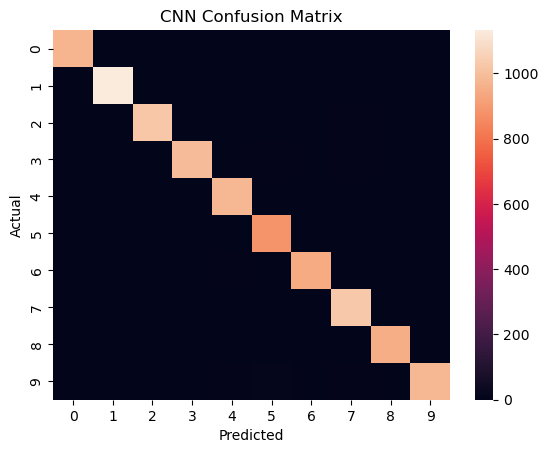

In [25]:
# Confusion Matrix

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure()
sns.heatmap(cm_cnn)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
## Model Comparison

In [27]:
print("Final Model Comparison:")
print("SVM Accuracy:", svm_accuracy)
print("DNN Accuracy:", dnn_accuracy)
print("CNN Accuracy:", cnn_accuracy)

Final Model Comparison:
SVM Accuracy: 0.917
DNN Accuracy: 0.9731000065803528
CNN Accuracy: 0.9886999726295471


In [28]:
## DNN Training Performance

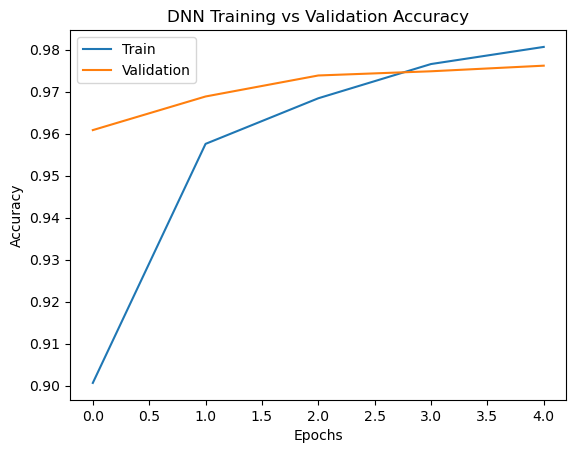

In [29]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("DNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [30]:
## CNN Training Performance

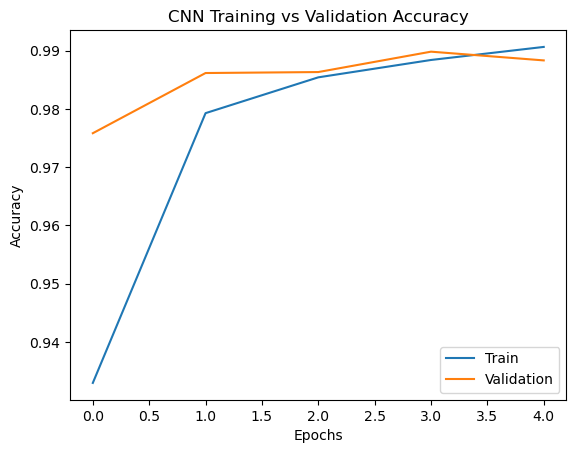

In [31]:
plt.figure()
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [32]:
## Loss Plot

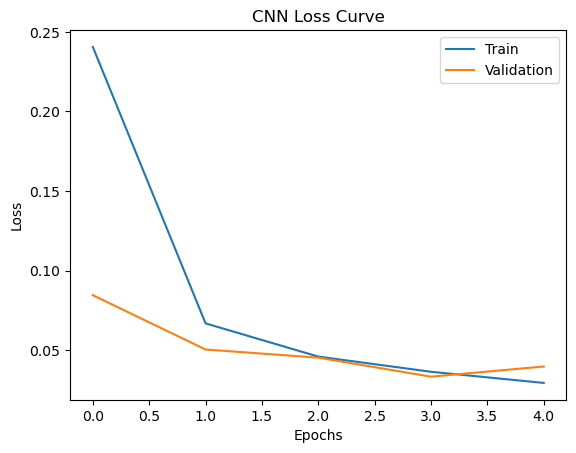

In [33]:
plt.figure()
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("CNN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()